<h1><center> ¿Cómo procesar palabras para construir un autocorrector? </center></h1>
    
<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

Todos los días usamos autocorrectores: en el celular y el computador. Esta es una función muy útil que nos permite corregir en tiempo de escritura una palabra sin tener que ajustar de forma manual, solo seleccionar la sugerencia correcta. Pero, ¿Cómo funciona un autocorrector?

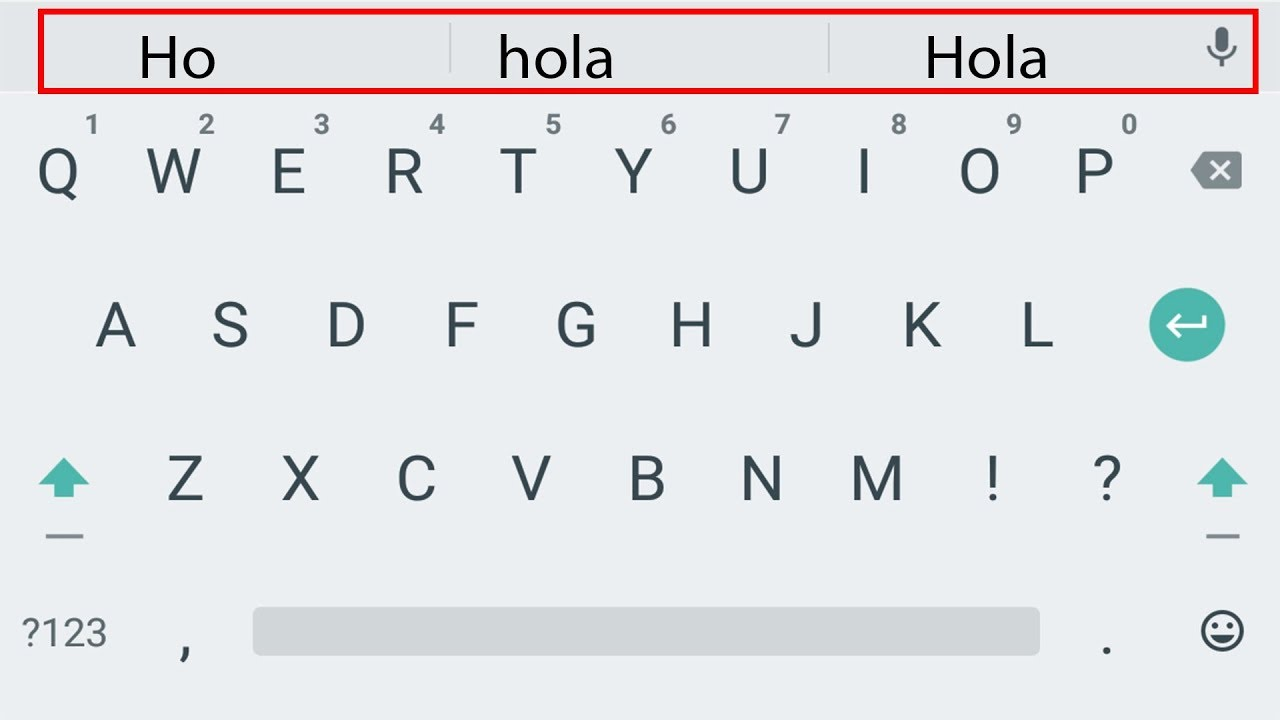

Este notebook tiene como proposito implementar un autocorrector siguiendo los pasos:
- Contar la cantidad de veces que aparece una palabra en un corpus
- Obtener la probabilidad de la palabra en el corpus
- Manipular la palabra (eliminar, combinar, reemplazar, insertar) caracteres -> tokens
- Implementar la distancia mínima para comparar strings.

In [1]:
import re
from collections import Counter
import numpy as np
import pandas as pd

### Carga y preprocesamiento de los datos

Como hemos visto, el primer paso será preprocesar los datos. Para ello, construiremos una función `process_data`, encargada de leer el corpus, convertir todas las palabras a *lowercase* y retornar la lista de palabras.

In [4]:
from nltk.corpus import cess_esp

sentences = cess_esp.sents()
print(sentences)

[['El', 'grupo', 'estatal', 'Electricité_de_France', '-Fpa-', 'EDF', '-Fpt-', 'anunció', 'hoy', ',', 'jueves', ',', 'la', 'compra', 'del', '51_por_ciento', 'de', 'la', 'empresa', 'mexicana', 'Electricidad_Águila_de_Altamira', '-Fpa-', 'EAA', '-Fpt-', ',', 'creada', 'por', 'el', 'japonés', 'Mitsubishi_Corporation', 'para', 'poner_en_marcha', 'una', 'central', 'de', 'gas', 'de', '495', 'megavatios', '.'], ['Una', 'portavoz', 'de', 'EDF', 'explicó', 'a', 'EFE', 'que', 'el', 'proyecto', 'para', 'la', 'construcción', 'de', 'Altamira_2', ',', 'al', 'norte', 'de', 'Tampico', ',', 'prevé', 'la', 'utilización', 'de', 'gas', 'natural', 'como', 'combustible', 'principal', 'en', 'una', 'central', 'de', 'ciclo', 'combinado', 'que', 'debe', 'empezar', 'a', 'funcionar', 'en', 'mayo_del_2002', '.'], ...]


ola -> hola -> cola -> aca -> prob. freq

In [5]:
def process_data():
    words = []
    sentences = cess_esp.sents()
    text = ""
    ### CODE ###
    for line in sentences:
        for word in line:
            text += word.lower() + " "
    return re.findall("\w+",text)

In [6]:
word_l = process_data()
vocab = set(word_l)  # this will be your new vocabulary
print(f"The first ten words in the text are: \n{word_l[0:10]}")
print(f"There are {len(vocab)} unique words in the vocabulary.")

The first ten words in the text are: 
['el', 'grupo', 'estatal', 'electricité_de_france', 'fpa', 'edf', 'fpt', 'anunció', 'hoy', 'jueves']
There are 24137 unique words in the vocabulary.


Una vez cargado nuestro corpus, el primer paso es contar la cantidad de veces que aparece una misma palabra. Para ello, implementaremos una función `get_count`, la cual retornará un diccionario donde la `key` será cada palabra y el `value` la cantidad de veces que aparece dicha palabra en el corpus:

In [7]:
def get_count(word_l):
    '''
    Input:
        word_l: a set of words representing the corpus. 
    Output:
        word_count_dict: The wordcount dictionary where key is the word and value is its frequency.
    '''
    word_count_dict = {}  # fill this with word counts
    ### CODE ### 
    for word in word_l:
        if word not in word_count_dict.keys():
            word_count_dict[word] = 1
        else:
            word_count_dict[word] += 1
    return word_count_dict

In [14]:
#DO NOT MODIFY THIS CELL
word_count_dict = get_count(word_l)
print(f"There are {len(word_count_dict)} key values pairs")
print(f"The count for the word 'casa' is {word_count_dict.get('casa',0)}")

There are 24137 key values pairs
The count for the word 'casa' is 51


In [ ]:
word_count_dict

Con el conteo de palabras realizado. Lo siguiente es obtener las probabilidades de cada palabra, las cuales están definidas así:

$$ P(w_i) = \frac{C(w_i)}{M} $$

Donde,

$C(w_i)$ Es el numero de veces que aparece la palabra $w_i$ en el corpus.

$M$ es el total de palabras en el corpus.

In [16]:
sum(word_count_dict.values())

171428

In [19]:
def get_probs(word_count_dict):
    '''
    Input:
        word_count_dict: The wordcount dictionary where key is the word and value is its frequency.
    Output:
        probs: A dictionary where keys are the words and the values are the probability that a word will occur. 
    '''
    probs = {}  # return this variable correctly
    total_w = sum(word_count_dict.values())
    for word in word_count_dict.keys():
        probs[word] = word_count_dict[word]/total_w
    ### CODE ###
    return probs

In [30]:
#DO NOT MODIFY THIS CELL
probs = get_probs(word_count_dict)
print(f"Length of probs is {len(probs)}")
test_w = "bajo"
print(f"P('{test_w}') is {probs[test_w]:.4f}")

Length of probs is 24137
P('bajo') is 0.0003


In [31]:
probs

{'el': 0.03507595025316751,
 'grupo': 0.0004666682222274074,
 'estatal': 4.666682222274074e-05,
 'electricité_de_france': 5.833352777842593e-06,
 'fpa': 0.004795015983386611,
 'edf': 2.9166763889212964e-05,
 'fpt': 0.004789182630608769,
 'anunció': 0.00022750075833586112,
 'hoy': 0.0020825069416898056,
 'jueves': 0.00015166717222390741,
 'la': 0.04039596798655996,
 'compra': 0.00012833376111253704,
 'del': 0.013189210630702101,
 '51_por_ciento': 1.1666705555685186e-05,
 'de': 0.06000186667288891,
 'empresa': 0.00036166787222624076,
 'mexicana': 4.083346944489815e-05,
 'electricidad_águila_de_altamira': 5.833352777842593e-06,
 'eaa': 1.750005833352778e-05,
 'creada': 3.500011666705556e-05,
 'por': 0.008995029983433277,
 'japonés': 9.333364444548149e-05,
 'mitsubishi_corporation': 5.833352777842593e-06,
 'para': 0.00769419231397438,
 'poner_en_marcha': 3.500011666705556e-05,
 'una': 0.008493361644538814,
 'central': 0.00015166717222390741,
 'gas': 8.750029166763889e-05,
 '495': 1.1666705

Hasta aquí, hemos construído un diccionario de probabilidades `probs` el cual contiene que tan probable es que aparezca una determinada palabra en el corpus. Ahora, necesitamos manipular el string para poder encontrar la palabra correcta (sin errores ortográficos).

- **delete_letter**: dada una palabra, retornamos todas las posibles palabras después de remover un caracter. -> `thola -> [hola, tola, thla, thol]`
- **switch_letter**: dada una palabra, retornamos todas las posibles palabras generadas al combinar dos caracteres adyacentes. `acma -> [cama, amca, acam]`
- **replace_letter**: dada una palabra, retornamos todas las posibles palabras después de reemplazar un caracter: `doma -> [aoma, boma, coma ..... domz]`
- **insert_letter**: dada una palabra, retornamos todas las posibles palabras generadas después de añadir un caracter: `oma -> [aoma, boma, coma, ...., omaz]`

Implementación de la función `delete_letter`:

Dada una palabra, por ejemplo "hola", debe retorna el conjunto: {"ola", "hla", "hol", "hoa"}

Una forma sencilla de hacerlos es dividir la palabra de izquierda a derecha, por ejemplo: `[('', 'hola'), ('h', 'ola'), ('ho', 'la'), ('hol', 'a'), ('hola', '')]`. Una vez definidos estos pares, lo que podemos hacer es tomar la secuencia de caracteres de la izquierda de una tupa, y de la derecha de la otra tupla y así obtendremos: `["ola", "hla", "hoa", "hol"]`


In [55]:
def delete_letter(word, verbose=False):
    '''
    Input:
        word: the string/word for which you will generate all possible words 
                in the vocabulary which have 1 missing character
    Output:
        delete_l: a list of all possible strings obtained by deleting 1 character from word
    '''
    
    delete_l = []
    split_l = []
    for idx in range(len(word)+1):
        split_l.append((word[:idx], word[idx:]))
    
    for l,r in split_l:
        if r:
            delete_l.append(l + r[1:])
    return  delete_l

In [37]:
delete_word_l = delete_letter(word="tcoma",
                        verbose=True)
print(delete_word_l)

l, r: [('', 'tcoma'), ('t', 'coma'), ('tc', 'oma'), ('tco', 'ma'), ('tcom', 'a'), ('tcoma', '')]
['coma', 'toma', 'tcma', 'tcoa', 'tcom']


Implementación de la función `switch_letter`:

Dada una palabra, por ejemplo "hola", debe retorna el conjunto: {"ohla", "hloa", "hoal"}

Una forma sencilla de hacerlos es dividir la palabra de izquierda a derecha, por ejemplo: `[('', 'hola'), ('h', 'ola'), ('ho', 'la'), ('hol', 'a'), ('hola', '')]`. Luego, tomar la parte izquierda y concatenar con los dos caracteres primeros de la parte derecha.

In [40]:
def switch_letter(word, verbose=False):
    '''
    Input:
        word: input string
     Output:
        switches: a list of all possible strings with one adjacent charater switched
    ''' 
    switch_l = []
    split_l = []
    
    for idx in range(len(word)+1):
        split_l.append((word[:idx], word[idx:]))
    
    for l,r in split_l:
        if len(r) > 1:
            switch_l.append(l + r[1] + r[0] + r[2:])
    
    return switch_l

In [42]:
switch_word_l = switch_letter(word="ocma",
                         verbose=True)

print(switch_word_l)

['coma', 'omca', 'ocam']


Implementación de la función `replace_ letter`:

Dada una palabra, por ejemplo "hola", debe retorna el conjunto de posibles palabras generadas al reemplazar cada caracter por el abecedario.

`[('', 'hola'), ('h', 'ola'), ('ho', 'la'), ('hol', 'a'), ('hola', '')]`

In [43]:
def replace_letter(word, verbose=False):
    '''
    Input:
        word: the input string/word 
    Output:
        replaces: a list of all possible strings where we replaced one letter from the original word. 
    ''' 
    
    letters = 'abcdefghijklmnñopqrstuvwxyz'
    
    replace_l = []
    split_l = []
    
    for idx in range(len(word)+1):
        split_l.append((word[:idx], word[idx:]))
        
    for w in letters:
        for l,r in split_l:
            if r:
                new_word = l + w + r[1:]
                if new_word != word:
                    replace_l.append(new_word)
                    
    replace_l = sorted(replace_l)
    
    return replace_l

In [45]:
replace_l = replace_letter(word='cpma',
                              verbose=True)

print(replace_l)

['apma', 'bpma', 'cama', 'cbma', 'ccma', 'cdma', 'cema', 'cfma', 'cgma', 'chma', 'cima', 'cjma', 'ckma', 'clma', 'cmma', 'cnma', 'coma', 'cpaa', 'cpba', 'cpca', 'cpda', 'cpea', 'cpfa', 'cpga', 'cpha', 'cpia', 'cpja', 'cpka', 'cpla', 'cpmb', 'cpmc', 'cpmd', 'cpme', 'cpmf', 'cpmg', 'cpmh', 'cpmi', 'cpmj', 'cpmk', 'cpml', 'cpmm', 'cpmn', 'cpmo', 'cpmp', 'cpmq', 'cpmr', 'cpms', 'cpmt', 'cpmu', 'cpmv', 'cpmw', 'cpmx', 'cpmy', 'cpmz', 'cpmñ', 'cpna', 'cpoa', 'cppa', 'cpqa', 'cpra', 'cpsa', 'cpta', 'cpua', 'cpva', 'cpwa', 'cpxa', 'cpya', 'cpza', 'cpña', 'cqma', 'crma', 'csma', 'ctma', 'cuma', 'cvma', 'cwma', 'cxma', 'cyma', 'czma', 'cñma', 'dpma', 'epma', 'fpma', 'gpma', 'hpma', 'ipma', 'jpma', 'kpma', 'lpma', 'mpma', 'npma', 'opma', 'ppma', 'qpma', 'rpma', 'spma', 'tpma', 'upma', 'vpma', 'wpma', 'xpma', 'ypma', 'zpma', 'ñpma']


Implementación de la función `insert_ letter`:

Dada una palabra, por ejemplo "hola", debe retorna el conjunto de posibles palabras generadas al insertar cada caracter del abecedario.

`[('', 'hola'), ('h', 'ola'), ('ho', 'la'), ('hol', 'a'), ('hola', '')]`

In [46]:
def insert_letter(word, verbose=False):
    '''
    Input:
        word: the input string/word 
    Output:
        inserts: a set of all possible strings with one new letter inserted at every offset
    ''' 
    letters = 'abcdefghijklmnñopqrstuvwxyz'
    insert_l = []
    split_l = []
    
    for idx in range(len(word)+1):
        split_l.append((word[:idx], word[idx:]))
        
    for w in letters:
        for l,r in split_l:
            insert_l.append(l + w + r)
    
    return insert_l

In [48]:
insert_l = insert_letter('ola', True)
print(f"Number of strings output by insert_letter('at') is {len(insert_l)}")
print(insert_l)

Number of strings output by insert_letter('at') is 108
['aola', 'oala', 'olaa', 'olaa', 'bola', 'obla', 'olba', 'olab', 'cola', 'ocla', 'olca', 'olac', 'dola', 'odla', 'olda', 'olad', 'eola', 'oela', 'olea', 'olae', 'fola', 'ofla', 'olfa', 'olaf', 'gola', 'ogla', 'olga', 'olag', 'hola', 'ohla', 'olha', 'olah', 'iola', 'oila', 'olia', 'olai', 'jola', 'ojla', 'olja', 'olaj', 'kola', 'okla', 'olka', 'olak', 'lola', 'olla', 'olla', 'olal', 'mola', 'omla', 'olma', 'olam', 'nola', 'onla', 'olna', 'olan', 'ñola', 'oñla', 'olña', 'olañ', 'oola', 'oola', 'oloa', 'olao', 'pola', 'opla', 'olpa', 'olap', 'qola', 'oqla', 'olqa', 'olaq', 'rola', 'orla', 'olra', 'olar', 'sola', 'osla', 'olsa', 'olas', 'tola', 'otla', 'olta', 'olat', 'uola', 'oula', 'olua', 'olau', 'vola', 'ovla', 'olva', 'olav', 'wola', 'owla', 'olwa', 'olaw', 'xola', 'oxla', 'olxa', 'olax', 'yola', 'oyla', 'olya', 'olay', 'zola', 'ozla', 'olza', 'olaz']


Hasta este punto, ya tenemos todas las palabras con un caracter modificado. Ahora, crearemos una función `edit_one_letter`, la cual recibe una palabra como entrada y retorna todas las posibles combinaciones entre las operaciónes de reemplazar, insertar, eliminar y combinar:

In [50]:
def edit_one_letter(word, allow_switches = True):
    """
    Input:
        word: the string/word for which we will generate all possible wordsthat are one edit away.
    Output:
        edit_one_set: a set of words with one possible edit. Please return a set. and not a list.
    """
    
    edit_one_set = set()
    
    edit_one_set = set(delete_letter(word)) | set (replace_letter(word)) | set (insert_letter(word)) | set(switch_letter(word))
    
    return set(edit_one_set)

In [52]:
tmp_word = "tma"
tmp_edit_one_set = edit_one_letter(tmp_word)
# turn this into a list to sort it, in order to view it
tmp_edit_one_l = sorted(list(tmp_edit_one_set))

print(f"input word {tmp_word} \nedit_one_l \n{tmp_edit_one_l}\n")
print(f"The type of the returned object should be a set {type(tmp_edit_one_set)}")
print(f"Number of outputs from edit_one_letter('cama') is {len(edit_one_letter(tmp_word))}")

l, r: [('', 'tma'), ('t', 'ma'), ('tm', 'a'), ('tma', '')]
input word tma 
edit_one_l 
['ama', 'atma', 'bma', 'btma', 'cma', 'ctma', 'dma', 'dtma', 'ema', 'etma', 'fma', 'ftma', 'gma', 'gtma', 'hma', 'htma', 'ima', 'itma', 'jma', 'jtma', 'kma', 'ktma', 'lma', 'ltma', 'ma', 'mma', 'mta', 'mtma', 'nma', 'ntma', 'oma', 'otma', 'pma', 'ptma', 'qma', 'qtma', 'rma', 'rtma', 'sma', 'stma', 'ta', 'taa', 'tam', 'tama', 'tba', 'tbma', 'tca', 'tcma', 'tda', 'tdma', 'tea', 'tema', 'tfa', 'tfma', 'tga', 'tgma', 'tha', 'thma', 'tia', 'tima', 'tja', 'tjma', 'tka', 'tkma', 'tla', 'tlma', 'tm', 'tmaa', 'tmab', 'tmac', 'tmad', 'tmae', 'tmaf', 'tmag', 'tmah', 'tmai', 'tmaj', 'tmak', 'tmal', 'tmam', 'tman', 'tmao', 'tmap', 'tmaq', 'tmar', 'tmas', 'tmat', 'tmau', 'tmav', 'tmaw', 'tmax', 'tmay', 'tmaz', 'tmañ', 'tmb', 'tmba', 'tmc', 'tmca', 'tmd', 'tmda', 'tme', 'tmea', 'tmf', 'tmfa', 'tmg', 'tmga', 'tmh', 'tmha', 'tmi', 'tmia', 'tmj', 'tmja', 'tmk', 'tmka', 'tml', 'tmla', 'tmm', 'tmma', 'tmn', 'tmna', 'tmo

#### Palabras sugeridas

In [67]:
def get_corrections(word, probs, vocab, n=3, verbose = False):
    '''
    Input: 
        word: a user entered string to check for suggestions
        probs: a dictionary that maps each word to its probability in the corpus
        vocab: a set containing all the vocabulary
        n: number of possible word corrections you want returned in the dictionary
    Output: 
        n_best: a list of tuples with the most probable n corrected words and their probabilities.
    '''
    
    suggestions = []
    n_best = []
    suggestion_probs = {}
    
    if word in vocab:
        return [(word, probs[word])]
    
    suggestions = edit_one_letter(word)
    
    if suggestions:
        for w in suggestions:
            if w in vocab:
                suggestion_probs[w] = probs[w]
            else:
                suggestion_probs[w] = 0
    else:
        return [(word, 1)]
    
    sorted_suggestion_probs = sorted(suggestion_probs.items(), key=lambda kv: kv[1], reverse=True)
    
    for i in range(n):
        sugg_prob = sorted_suggestion_probs[i][1]
        if sugg_prob != 0:
            n_best.append((sorted_suggestion_probs[i][0], sorted_suggestion_probs[i][1]))
            
    print(sorted_suggestion_probs)
    
    if verbose: print("entered word = ", word, "\nsuggestions = ", suggestions)

    return n_best

In [68]:
# Test your implementation - feel free to try other words in my word
my_word = 'ler' 
tmp_corrections = get_corrections(my_word, probs, vocab, 20, verbose=False) # keep verbose=True
for i, word_prob in enumerate(tmp_corrections):
    print(f"word {i}: {word_prob[0]}, probability {word_prob[1]:.6f}")

# CODE REVIEW COMMENT: using "tmp_corrections" insteads of "cors". "cors" is not defined
print(f"data type of corrections {type(tmp_corrections)}")

[('le', 0.0018375061250204168), ('ser', 0.0013183377277924259), ('les', 0.00043750145833819446), ('ver', 0.0002566675222250741), ('ley', 0.00020416734722449075), ('per', 4.083346944489815e-05), ('leer', 2.333341111137037e-05), ('oler', 1.1666705555685186e-05), ('lei', 5.833352777842593e-06), ('lee', 5.833352777842593e-06), ('lel', 0), ('leri', 0), ('llr', 0), ('fer', 0), ('vler', 0), ('len', 0), ('lvr', 0), ('lerñ', 0), ('lwer', 0), ('mer', 0), ('leru', 0), ('lerl', 0), ('lier', 0), ('sler', 0), ('wer', 0), ('lerd', 0), ('lerm', 0), ('ljer', 0), ('lerx', 0), ('lerr', 0), ('levr', 0), ('lyr', 0), ('loer', 0), ('iler', 0), ('lex', 0), ('ner', 0), ('lez', 0), ('lrr', 0), ('leg', 0), ('jler', 0), ('ber', 0), ('yler', 0), ('lgr', 0), ('lery', 0), ('lzer', 0), ('lerc', 0), ('oer', 0), ('mler', 0), ('lñr', 0), ('lev', 0), ('xler', 0), ('lner', 0), ('luer', 0), ('leor', 0), ('leñ', 0), ('lcr', 0), ('lber', 0), ('lrer', 0), ('fler', 0), ('leb', 0), ('let', 0), ('lekr', 0), ('led', 0), ('leyr', 